<a href="https://colab.research.google.com/github/arlinrus/vkr/blob/main/diplom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data load

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
# %%capture
# !pip install --upgrade matplotlib numpy==1.26.0 # need refresh enviroment after installation

In [9]:
# %%capture
# !pip install basemap phik sweetviz

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
data_purchases = pd.read_csv('/content/drive/MyDrive/Diplom/amazon-purchases.csv', na_values=['NaN'])

In [13]:
data_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Order Date                object 
 1   Purchase Price Per Unit   float64
 2   Quantity                  float64
 3   Shipping Address State    object 
 4   Title                     object 
 5   ASIN/ISBN (Product Code)  object 
 6   Category                  object 
 7   Survey ResponseID         object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


In [14]:
data_purchases.dtypes

,0
Order Date,object
Purchase Price Per Unit,float64
Quantity,float64
Shipping Address State,object
Title,object
ASIN/ISBN (Product Code),object
Category,object
Survey ResponseID,object


In [15]:
data_purchases.isnull().sum()


,0
Order Date,0
Purchase Price Per Unit,0
Quantity,0
Shipping Address State,87812
Title,89740
ASIN/ISBN (Product Code),973
Category,89458
Survey ResponseID,0


# DATA PREPROCESSING

Преобразуем тип данных, название стообцов, и пропуски в датасете.

In [16]:
df = data_purchases.copy()

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['total_price'] = (df['purchase_price_per_unit'] * df['quantity'])

df = df.rename(columns={
    'survey_responseid':'user_id',
    'asin_isbn_product_code': 'asin_isbn',
})

df.columns

# new_col_names = [
#     re.sub(r"\s+", "_", s.strip().lower())
#     for s in data_purchases.columns
# ]

Index(['order_date', 'purchase_price_per_unit', 'quantity',
       'shipping_address_state', 'title', 'asin_isbn', 'category', 'user_id',
       'total_price'],
      dtype='object')

In [17]:
cols = list(df.columns)
cols[0], cols[7] = cols[7], cols[0]
df = df[cols]

In [18]:
df.head()

,user_id,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,order_date,total_price
0,R_01vNIayewjIIKMF,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,2018-12-04,7.98
1,R_01vNIayewjIIKMF,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,2018-12-22,13.99
2,R_01vNIayewjIIKMF,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,2018-12-24,8.99
3,R_01vNIayewjIIKMF,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,2018-12-25,10.45
4,R_01vNIayewjIIKMF,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,2018-12-25,10.00


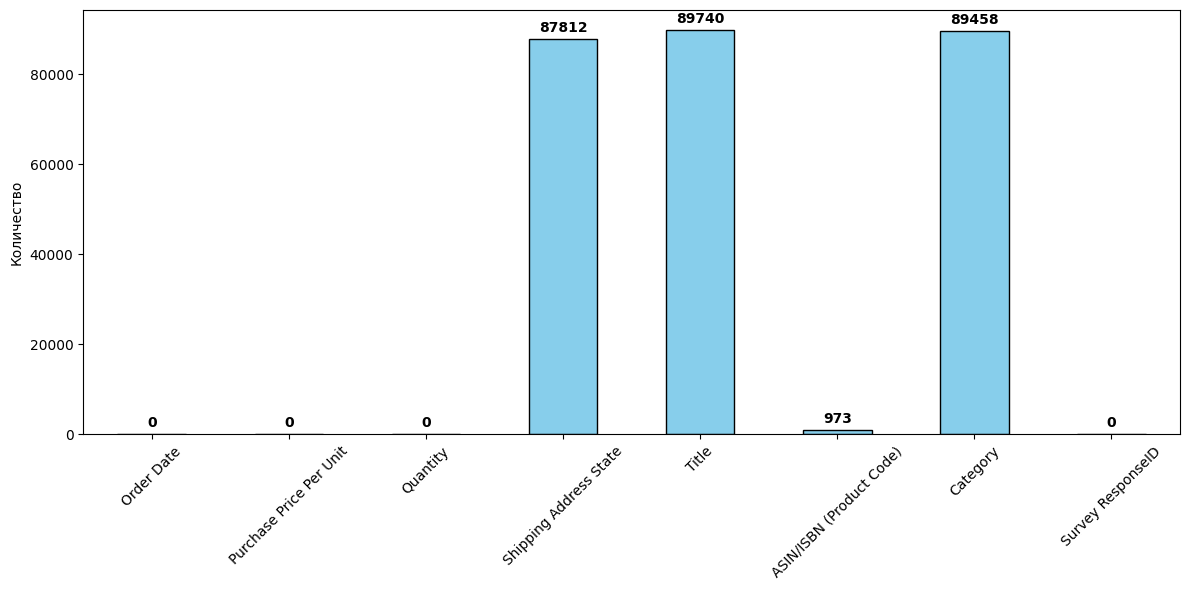

In [19]:
missing_value = data_purchases.isna().sum()
ax = missing_value.plot(kind='bar', legend=False, color='skyblue', edgecolor='black', linestyle='-', rot=45, figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3, fontweight='bold')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Обработаем пропуски в категориальных данных

In [20]:
df['shipping_address_state'] = df['shipping_address_state'].fillna('uknown')
df['category'] = df['category'].fillna('uknown')
df['title'] = df['title'].fillna('uknown')
df['asin_isbn'] = df['asin_isbn'].fillna('uknown')


In [21]:
df.isnull().sum()

,0
user_id,0
purchase_price_per_unit,0
quantity,0
shipping_address_state,0
title,0
asin_isbn,0
category,0
order_date,0
total_price,0


In [22]:
df.shape, df['user_id'].nunique(), df['category'].nunique(), df['order_date'].min(), df['order_date'].max()

((1850717, 9),
 5027,
 1872,
 Timestamp('2018-01-01 00:00:00'),
 Timestamp('2024-08-15 00:00:00'))

## 3. Первичный EDA транзакционного уровня

На этом этапе анализируются сами транзакции: распределение цен, количества товаров, общей стоимости заказа, динамика покупок во времени и пропуски.

Определим правильно квартили в датасете

In [23]:
num_cols_transaction = ['purchase_price_per_unit', 'quantity', 'total_price']
df[num_cols_transaction].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
purchase_price_per_unit,1850717.0,22.659063,45.999671,0.01,1.06,2.99,8.47,13.99,23.75,59.99,174.9900,6398.95
quantity,1850717.0,1.088636,0.779534,1.00,1.00,1.00,1.00,1.00,1.00,2.00,3.0000,339.00
total_price,1850717.0,23.803549,49.219424,0.01,1.34,3.43,8.95,14.75,24.95,64.99,182.3984,6398.95


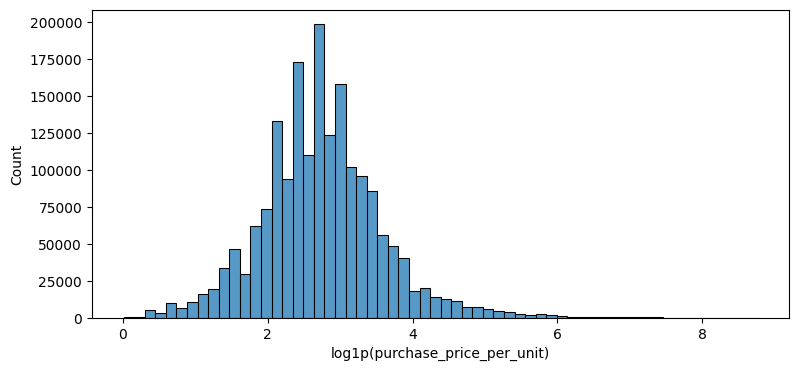

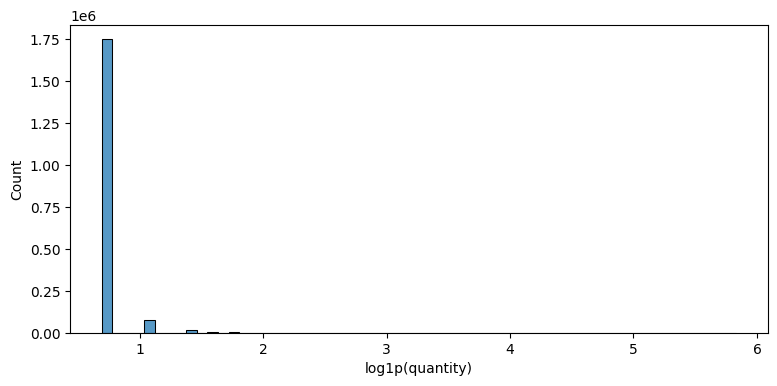

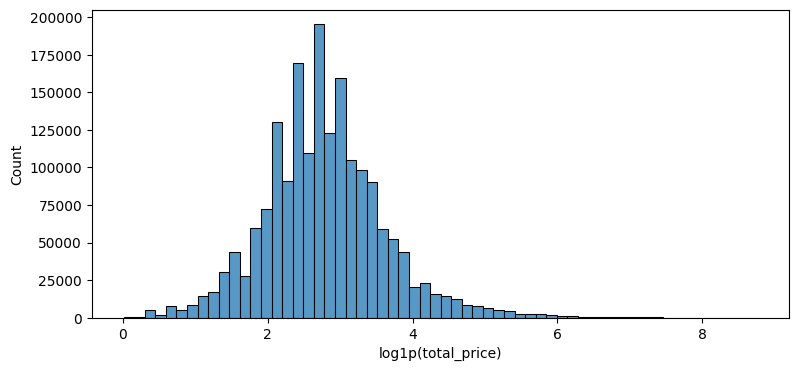

In [24]:
for col in num_cols_transaction:
    plt.figure(figsize=(9, 4))
    sns.histplot(np.log1p(df[col]), bins=60)
    plt.xlabel(f'log1p({col})')
    plt.show()


In [25]:
month_orders = df.set_index('order_date').resample('M')['user_id'].count()
month_revenue = df.set_index('order_date').resample('M')['total_price'].sum()

Построим график количества транзакций и выручку за месяц

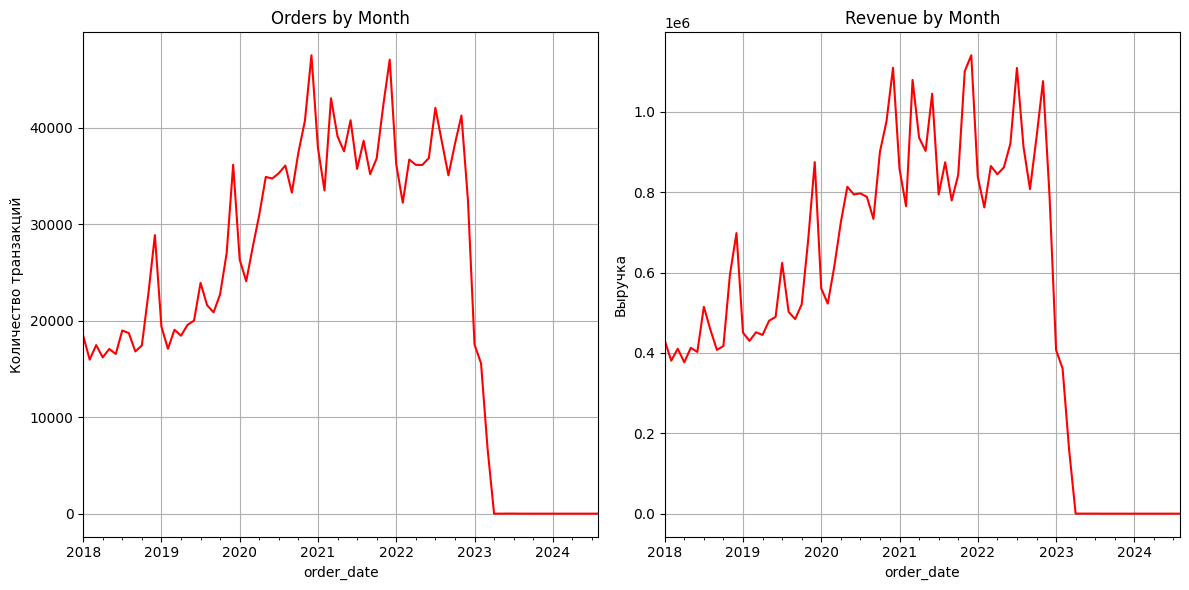

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

month_orders.plot(
    kind='line',
    color='red',
    grid=True,
    ax=ax[0]
)
ax[0].set_title('Orders by Month')
ax[0].set_ylabel('Количество транзакций')

month_revenue.plot(
    kind='line',
    color='red',
    grid=True,
    ax=ax[1]
)
ax[1].set_title('Revenue by Month')
ax[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [27]:
# сколько раз каждый пользователь покупал товар
count_user = df.groupby(['user_id', 'asin_isbn']).size().reset_index(name='product_purch')
repeat = count_user[(count_user['product_purch'] > 1) & (count_user['product_purch'] < 7)]
item = repeat['product_purch'].value_counts().sort_index()
pie_data = item[item.index > 5].copy()
pie_data['>5'] = item[item.index > 5].sum()

labels = [str(i) for i in pie_data.index]

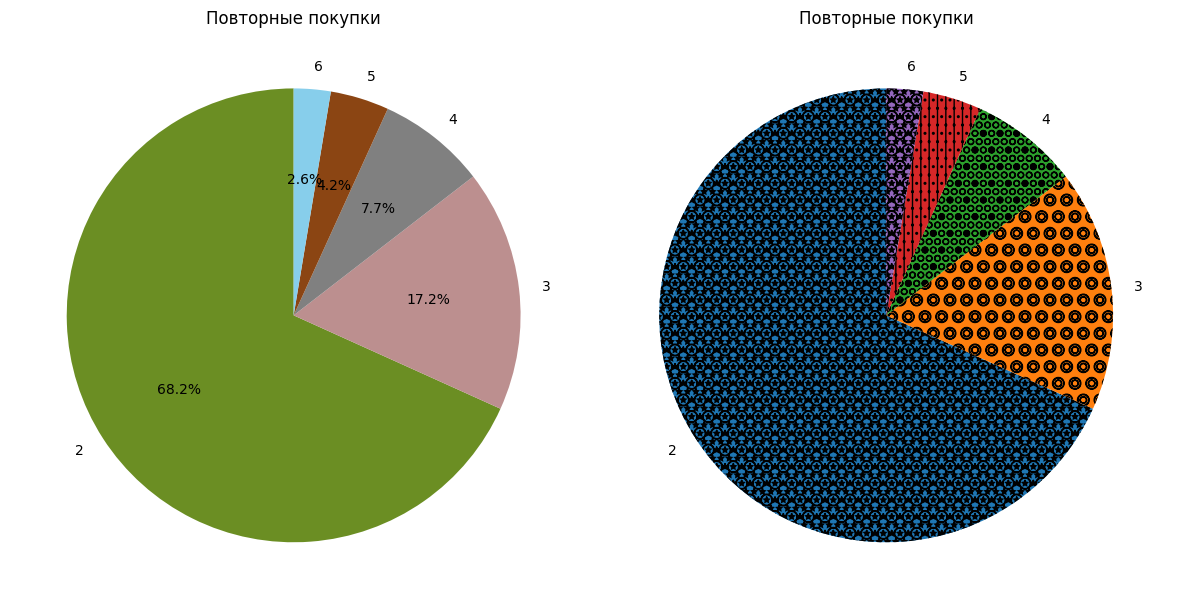

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

item.plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    colors=['olivedrab', 'rosybrown', 'gray', 'saddlebrown', 'skyblue']
)

item.plot(
    kind='pie',
    ax=axes[1],
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    hatch=['**O', 'oO', 'O.O', '.||.']
)

plt.tight_layout()
plt.show()

In [29]:
cutoff_date = pd.Timestamp('2021-01-01')
end_date = pd.Timestamp('2023-03-31')

df = df[df['order_date'] <= end_date]

past = df[df['order_date'] < cutoff_date].copy()
future = df[df['order_date'] >= cutoff_date].copy()
past.shape, future.shape, past['user_id'].nunique(), future['user_id'].nunique()

((900693, 9), (950006, 9), 4882, 4978)

In [30]:
ltv = (
    future.groupby('user_id')['total_price']
    .sum()
    .rename('ltv')
    .reset_index()
)

# Feature engineering

Сейчас произведем рассчеты и защитим некоторые столбцы от деления на 0

In [31]:
def category_entropy(x):
  counts = x.value_counts(normalize=True)
  return - (counts * np.log1p(counts)).sum()

user = past.groupby('user_id').agg(
    total_revenue=('total_price', 'sum'),
    num_orders=('total_price', 'count'),
    total_quantity=('quantity', 'sum'),
    avg_order_value=('total_price', 'mean'),
    median_order_value=('total_price', 'median'),
    std_order_value=('total_price', 'std'),
    min_order_value=('total_price', 'min'),
    max_order_value=('total_price', 'max'),
    avg_unit_price=('purchase_price_per_unit', 'mean'),
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max'),
    active_days=('order_date', lambda x: x.dt.date.nunique()),
    category_count=('category', 'nunique'),
    product_count=('asin_isbn', 'nunique'),
    state_count=('shipping_address_state', 'nunique'),
    category_entropy=('category', category_entropy)
).reset_index()

Рассчитаем временные признаки

In [32]:
user['recency'] = (cutoff_date - user['last_order_date']).dt.days
user['customer_age'] = (cutoff_date - user['first_order_date']).dt.days #время с момента первого взаимодействия
user['tenure'] = (user['last_order_date'] -user['first_order_date']).dt.days #длительность активного периода

In [33]:
#если покупатель ничего не покупает - это не значит, что у него ничего нету, поэтому вместо 0 у нас засчитывается как один день
user['zero_division_customer'] = user['customer_age'].replace(0, 1)
user['zero_division_tenure'] = user['tenure'].replace(0, 1)

In [34]:
# Интенсивность поведения
user['purchase_frequency_rate'] = user['num_orders'] / user['zero_division_customer']
user['revenue_per_day'] = user['total_revenue'] / user['zero_division_customer']
user['orders_per_active_day'] = user['num_orders'] / user['active_days'].replace(0, 1)
user['active_days_ratio'] = user['active_days'] / user['zero_division_customer']
user['average_order_size'] = user['total_quantity'] / user['num_orders'].replace(0, 1)
user['recency_normalized'] = user['recency'] / user['zero_division_customer']


In [35]:
user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,customer_age,tenure,zero_division_customer,zero_division_tenure,purchase_frequency_rate,revenue_per_day,orders_per_active_day,active_days_ratio,average_order_size,recency_normalized
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,759,633,759,633,0.117260,2.547879,1.679245,0.069829,1.044944,0.166008
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,1079,1078,1079,1078,0.423540,6.577609,3.410448,0.124189,1.078775,0.000927
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,745,731,745,731,0.040268,2.191718,2.142857,0.018792,1.100000,0.018792
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,1084,775,1084,775,0.050738,0.948681,1.896552,0.026753,1.000000,0.285055
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,1074,1071,1074,1071,0.183426,4.487356,2.814286,0.065177,1.081218,0.002793


In [36]:
user.columns

Index(['user_id', 'total_revenue', 'num_orders', 'total_quantity',
       'avg_order_value', 'median_order_value', 'std_order_value',
       'min_order_value', 'max_order_value', 'avg_unit_price',
       'first_order_date', 'last_order_date', 'active_days', 'category_count',
       'product_count', 'state_count', 'category_entropy', 'recency',
       'customer_age', 'tenure', 'zero_division_customer',
       'zero_division_tenure', 'purchase_frequency_rate', 'revenue_per_day',
       'orders_per_active_day', 'active_days_ratio', 'average_order_size',
       'recency_normalized'],
      dtype='object')

Рассчитаем интервалы между покупками

In [37]:
past_n = past.sort_values(['user_id', 'order_date']).copy()
past_n['days_between_orders_'] = past_n.groupby('user_id')['order_date'].diff().dt.days

In [38]:
past_n

,user_id,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,order_date,total_price,days_between_orders_
0,R_01vNIayewjIIKMF,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,2018-12-04,7.98,NaN
1,R_01vNIayewjIIKMF,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,2018-12-22,13.99,18.0
2,R_01vNIayewjIIKMF,8.99,1.0,NJ,uknown,B078JZTFN3,uknown,2018-12-24,8.99,2.0
3,R_01vNIayewjIIKMF,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,2018-12-25,10.45,1.0
4,R_01vNIayewjIIKMF,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,2018-12-25,10.00,0.0
...,...,...,...,...,...,...,...,...,...,...
1850706,R_zfqnsBzlOAKibzb,6.68,1.0,MA,Greeks and Their Gods,0807057932,ABIS_BOOK,2019-09-30,6.68,47.0
1850707,R_zfqnsBzlOAKibzb,16.90,1.0,MA,"MIZON Snail Repair Cream, Face Moisturizer wit...",B00AF63QQE,SKIN_MOISTURIZER,2019-10-13,16.90,13.0
1850708,R_zfqnsBzlOAKibzb,3.77,7.0,MA,"Tomcat Press 'N Set Mouse Trap, 2 Traps",B00N6XKVNY,PEST_CONTROL_DEVICE,2020-01-12,26.39,91.0
1850709,R_zfqnsBzlOAKibzb,41.99,1.0,MA,HD Webcam 1080P Streaming Web Camera with Micr...,B085WXGMWG,CAMCORDER,2020-03-24,41.99,72.0


In [39]:
interval_features = past_n.groupby('user_id')['days_between_orders_'].agg(
    avg_days_between_orders='mean',
    median_days_between_orders='median',
    std_days_between_orders='std',
    min_days_between_orders='min',
    max_days_between_orders='max'
).reset_index()

user = user.merge(interval_features, on='user_id', how='left')
user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,revenue_per_day,orders_per_active_day,active_days_ratio,average_order_size,recency_normalized,avg_days_between_orders,median_days_between_orders,std_days_between_orders,min_days_between_orders,max_days_between_orders
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,2.547879,1.679245,0.069829,1.044944,0.166008,7.193182,1.0,10.853103,0.0,55.0
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,6.577609,3.410448,0.124189,1.078775,0.000927,2.364035,0.0,6.319961,0.0,59.0
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,2.191718,2.142857,0.018792,1.100000,0.018792,25.206897,0.0,46.414575,0.0,175.0
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,0.948681,1.896552,0.026753,1.000000,0.285055,14.351852,1.0,38.296833,0.0,207.0
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,4.487356,2.814286,0.065177,1.081218,0.002793,5.464286,0.0,11.086779,0.0,65.0


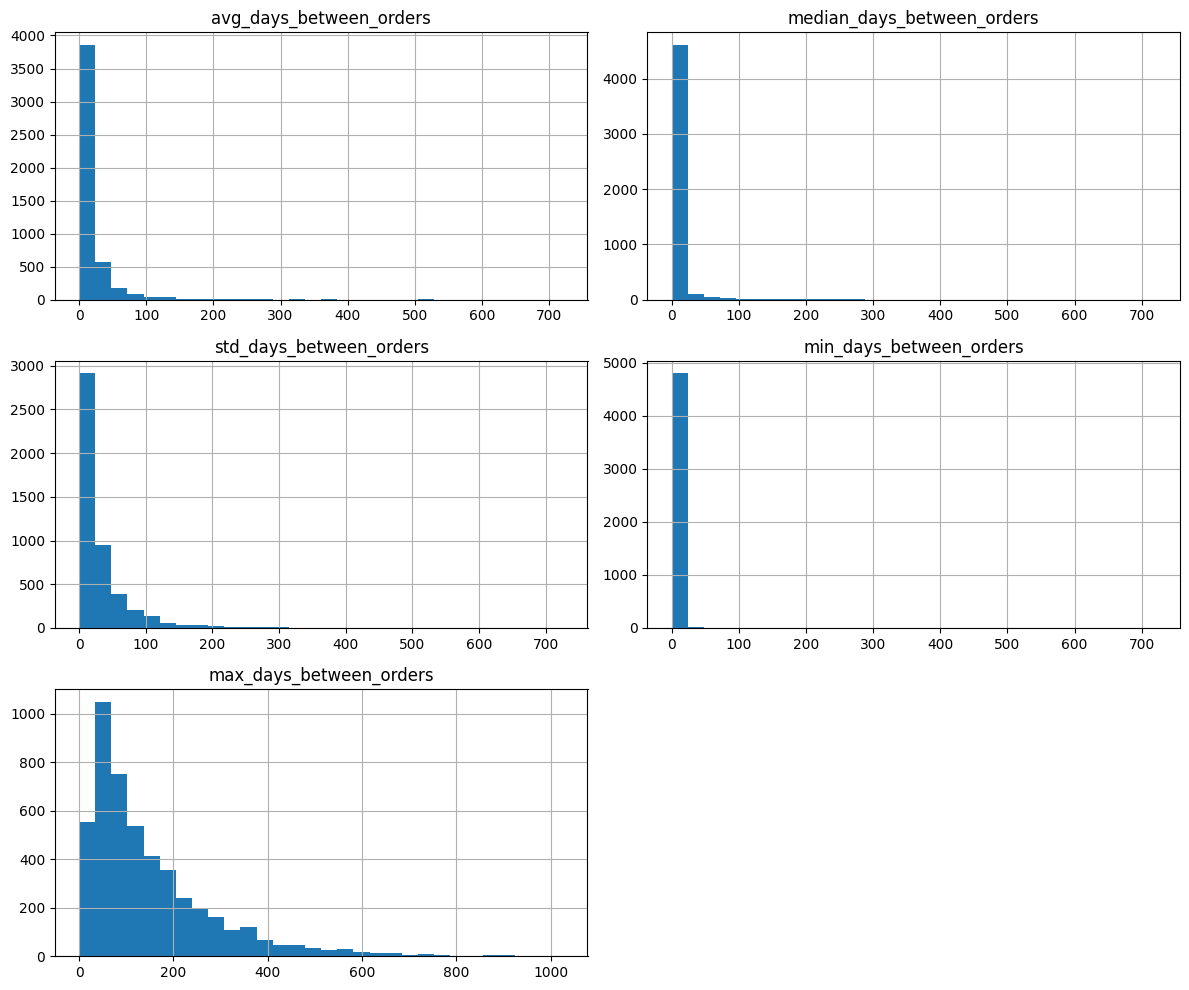

In [40]:
cols = [
    'avg_days_between_orders',
    'median_days_between_orders',
    'std_days_between_orders',
    'min_days_between_orders',
    'max_days_between_orders'
]

user[cols].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

Признаки первых 30 дней после первой покупки помогают понять, насколько быстро пользователь начинает приносить ценность.

In [41]:
first_day = past.groupby('user_id')['order_date'].min().rename('first_date')
past_early = past.merge(first_day, on='user_id', how='left')
past_early['days_from_start'] = (past_early['order_date'] - past_early['first_date']).dt.days

In [42]:
early_30 = past_early[past_early['days_from_start'] <= 30]
early_features = early_30.groupby('user_id').agg(
    revenue_first_30d=('total_price', 'sum'),
    orders_first_30d=('total_price', 'count'),
    quantity_first_30d=('quantity', 'sum'),
    categories_first_30d=('category', 'nunique')
).reset_index()

early_features['avg_order_value_first_30d'] = (
    early_features['revenue_first_30d'] / early_features['orders_first_30d'].replace(0, np.nan)
)

user = user.merge(early_features, on='user_id', how='left')
user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,avg_days_between_orders,median_days_between_orders,std_days_between_orders,min_days_between_orders,max_days_between_orders,revenue_first_30d,orders_first_30d,quantity_first_30d,categories_first_30d,avg_order_value_first_30d
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,7.193182,1.0,10.853103,0.0,55.0,51.41,5,5.0,5,10.282000
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,2.364035,0.0,6.319961,0.0,59.0,212.66,26,29.0,20,8.179231
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,25.206897,0.0,46.414575,0.0,175.0,61.88,2,2.0,2,30.940000
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,14.351852,1.0,38.296833,0.0,207.0,10.99,1,1.0,1,10.990000
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,5.464286,0.0,11.086779,0.0,65.0,17.99,1,1.0,1,17.990000


### 5.3 Доля топ-категории

Этот признак отражает специализацию покупок. Если большая часть заказов приходится на одну категорию, пользователь имеет более устойчивый категорийный паттерн.

In [43]:
cat_counts = past.groupby(['user_id', 'category']).size().rename('cat_orders').reset_index()
top_cat = cat_counts.loc[cat_counts.groupby('user_id')['cat_orders'].idxmax()].copy()
total_orders_by_user = past.groupby('user_id').size().rename('num_orders_check').reset_index()

top_cat = top_cat.merge(total_orders_by_user, on='user_id', how='left')
top_cat['top_category_share'] = top_cat['cat_orders'] / top_cat['num_orders_check']
top_cat = top_cat[['user_id', 'category', 'top_category_share']].rename(columns={'category': 'top_category'})

user = user.merge(top_cat, on='user_id', how='left')
user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,std_days_between_orders,min_days_between_orders,max_days_between_orders,revenue_first_30d,orders_first_30d,quantity_first_30d,categories_first_30d,avg_order_value_first_30d,top_category,top_category_share
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,10.853103,0.0,55.0,51.41,5,5.0,5,10.282000,HEADPHONES,0.123596
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,6.319961,0.0,59.0,212.66,26,29.0,20,8.179231,PET_FOOD,0.080963
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,46.414575,0.0,175.0,61.88,2,2.0,2,30.940000,DIGITAL_DEVICE_3,0.133333
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,38.296833,0.0,207.0,10.99,1,1.0,1,10.990000,COAT,0.090909
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,11.086779,0.0,65.0,17.99,1,1.0,1,17.990000,ABIS_BOOK,0.065990


### 5.4 Тренды активности

Сравниваем последние 90 дней исторического периода с предыдущими 90 днями. Это позволяет увидеть рост или падение активности до даты отсечения.

In [44]:
last_90_start = cutoff_date - pd.Timedelta(days=90)
prev_90_start = cutoff_date - pd.Timedelta(days=180)

last_90 = past[(past['order_date'] >= last_90_start) & (past['order_date'] < cutoff_date)]
prev_90 = past[(past['order_date'] >= prev_90_start) & (past['order_date'] < last_90_start)]

last_90_features = last_90.groupby('user_id').agg(
    revenue_last_90d=('total_price', 'sum'),
    orders_last_90d=('total_price', 'count')
).reset_index()

prev_90_features = prev_90.groupby('user_id').agg(
    revenue_prev_90d=('total_price', 'sum'),
    orders_prev_90d=('total_price', 'count')
).reset_index()

user = user.merge(last_90_features, on='user_id', how='left')
user = user.merge(prev_90_features, on='user_id', how='left')

for col in ['revenue_last_90d', 'orders_last_90d', 'revenue_prev_90d', 'orders_prev_90d']:
    user[col] = user[col].fillna(0)

user['revenue_trend_90d'] = (user['revenue_last_90d'] + 1) / (user['revenue_prev_90d'] + 1)
user['orders_trend_90d'] = (user['orders_last_90d'] + 1) / (user['orders_prev_90d'] + 1)

user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,categories_first_30d,avg_order_value_first_30d,top_category,top_category_share,revenue_last_90d,orders_last_90d,revenue_prev_90d,orders_prev_90d,revenue_trend_90d,orders_trend_90d
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,5,10.282000,HEADPHONES,0.123596,0.00,0.0,349.56,9.0,0.002853,0.10
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,20,8.179231,PET_FOOD,0.080963,1518.75,78.0,745.34,49.0,2.036270,1.58
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,2,30.940000,DIGITAL_DEVICE_3,0.133333,748.97,9.0,0.00,0.0,749.970000,10.00
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,1,10.990000,COAT,0.090909,0.00,0.0,0.00,0.0,1.000000,1.00
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,1,17.990000,ABIS_BOOK,0.065990,924.45,49.0,516.36,24.0,1.788793,2.00


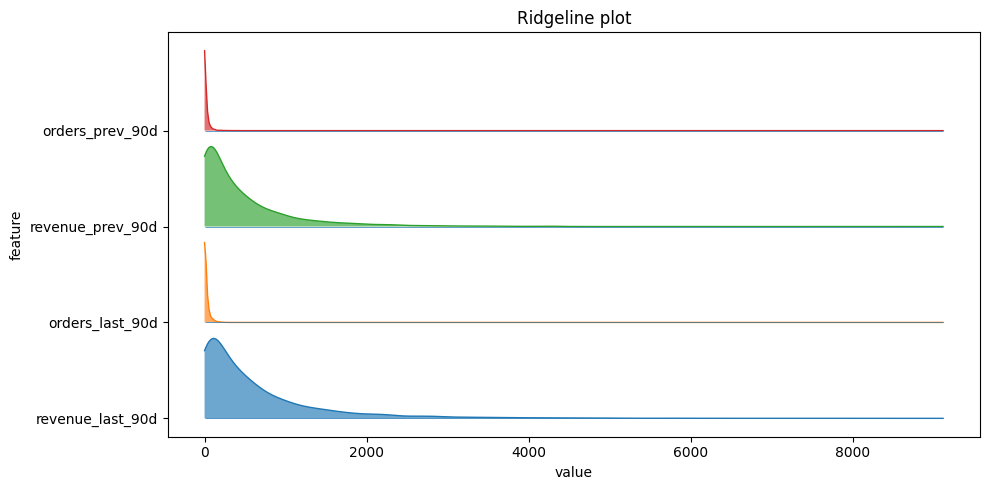

In [45]:
from scipy.stats import gaussian_kde

cols = [
    'revenue_last_90d',
    'orders_last_90d',
    'revenue_prev_90d',
    'orders_prev_90d'
]

data = user[cols].copy()

fig, ax = plt.subplots(figsize=(10, 5))

offset = 1.2
x_min = data.min().min()
x_max = data.max().max()
x = np.linspace(x_min, x_max, 500)

for i, col in enumerate(data.columns):
    values = data[col].dropna()
    kde = gaussian_kde(values)
    y = kde(x)
    y = y / y.max()

    baseline = i * offset

    ax.fill_between(x, baseline, baseline + y, alpha=0.65)
    ax.plot(x, baseline + y, linewidth=1)
    ax.hlines(baseline, x_min, x_max, linewidth=0.5)

ax.set_yticks(np.arange(len(data.columns)) * offset)
ax.set_yticklabels(data.columns)

ax.set_xlabel("value")
ax.set_ylabel("feature")
ax.set_title("Ridgeline plot")

plt.tight_layout()
plt.show()

In [46]:
user["revenue_last_90d"].quantile([0.5, 0.9, 0.95, 0.99])

,revenue_last_90d
0.50,332.4950
0.90,1526.9200
0.95,2181.6555
0.99,3841.7719


In [47]:
user["revenue_delta"] = user["revenue_last_90d"] - user["revenue_prev_90d"]
user["orders_delta"] = user["orders_last_90d"] - user["orders_prev_90d"]

### 5.5 Бинарные поведенческие флаги

In [48]:
user['is_repeat_buyer'] = (user['num_orders'] > 1).astype(int)
user['is_recent_buyer_90d'] = (user['recency'] <= 90).astype(int)
user['has_many_categories'] = (user['category_count'] > user['category_count'].median()).astype(int)

user.head()

,user_id,total_revenue,num_orders,total_quantity,avg_order_value,median_order_value,std_order_value,min_order_value,max_order_value,avg_unit_price,...,orders_last_90d,revenue_prev_90d,orders_prev_90d,revenue_trend_90d,orders_trend_90d,revenue_delta,orders_delta,is_repeat_buyer,is_recent_buyer_90d,has_many_categories
0,R_01vNIayewjIIKMF,1933.84,89,93.0,21.728539,14.33,25.183322,1.99,150.00,20.328652,...,0.0,349.56,9.0,0.002853,0.10,-349.56,-9.0,1,0,0
1,R_037XK72IZBJyF69,7097.24,457,493.0,15.530066,11.97,18.549262,0.75,210.55,14.902757,...,78.0,745.34,49.0,2.036270,1.58,773.41,29.0,1,1,1
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,54.427667,29.99,74.494501,1.99,399.98,47.103333,...,9.0,0.00,0.0,749.970000,10.00,748.97,9.0,1,1,0
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,11.73,21.780379,2.29,99.99,18.697636,...,0.0,0.00,0.0,1.000000,1.00,0.00,0.0,1,0,0
4,R_06RZP9pS7kONINr,4819.42,197,213.0,24.464061,16.59,31.156969,2.98,305.00,23.428477,...,49.0,516.36,24.0,1.788793,2.00,408.09,25.0,1,1,1


## 6. Итоговый датасет для моделирования

In [49]:
data = user.merge(ltv, on='user_id', how='left')
data['ltv'] = data['ltv'].fillna(0)
data['ltv_log'] = np.log1p(data['ltv'])

date_cols = ['first_order_date', 'last_order_date']

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col not in ['ltv', 'ltv_log']:
        data[col] = data[col].replace([np.inf, -np.inf], np.nan)
        data[col] = data[col].fillna(0)

for col in ['top_category']:
    data[col] = data[col].fillna('unknown')

data.shape

(4882, 53)

In [50]:
data[['ltv', 'ltv_log']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ltv,4882.0,4621.403410,5347.976168,0.0,3.587200,187.523500,1153.620000,2966.435000,6164.455000,14508.781000,24581.636100,75077.590000
ltv_log,4882.0,7.750695,1.490462,0.0,1.502342,5.239222,7.051526,7.995453,8.726717,9.582578,10.109794,11.226291


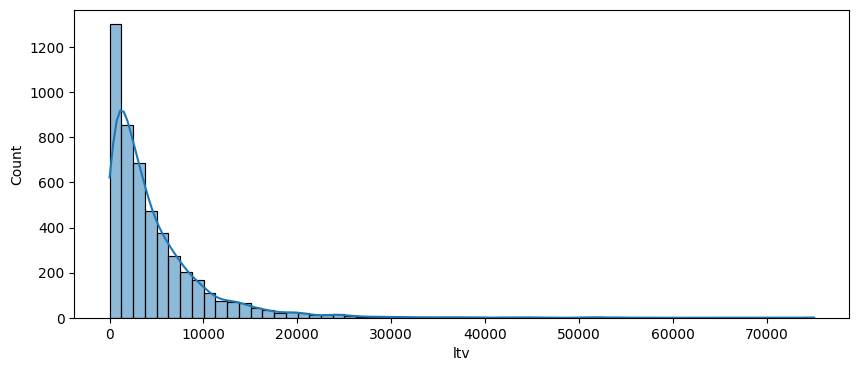

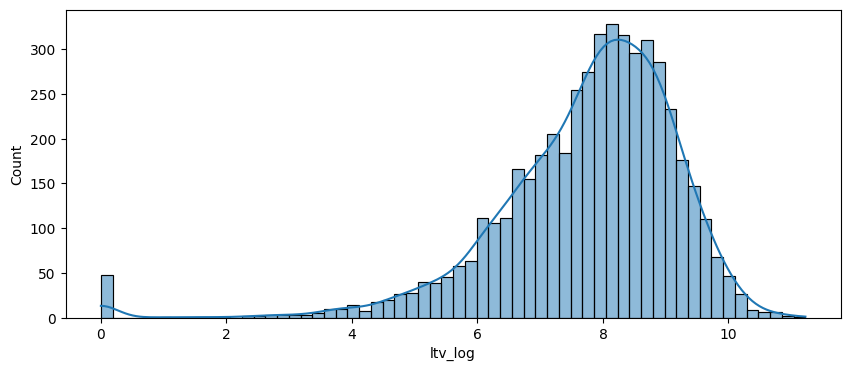

In [51]:
plt.figure(figsize=(10, 4))
sns.histplot(data['ltv'], bins=60, kde=True)
# plt.title('Распределение LTV')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(data['ltv_log'], bins=60, kde=True)
# plt.title('Распределение log1p(LTV)')
plt.show()

In [52]:
important_features = [
    'total_revenue', 'num_orders', 'avg_order_value', 'median_order_value', 'std_order_value',
    'recency', 'customer_age', 'tenure', 'purchase_frequency_rate', 'revenue_per_day',
    'avg_days_between_orders', 'std_days_between_orders', 'category_count', 'product_count',
    'top_category_share', 'revenue_first_30d', 'orders_first_30d',
    'revenue_last_90d', 'orders_last_90d', 'revenue_trend_90d', 'orders_trend_90d'
]

available_important_features = [c for c in important_features if c in data.columns]

data[available_important_features + ['ltv', 'ltv_log']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_revenue,4882.0,4358.614244,5179.882037,3.930000,29.919700,130.491000,937.422500,2638.260000,5794.762500,14535.997000,24537.337500,60848.980000
num_orders,4882.0,184.492626,224.618126,1.000000,1.000000,7.000000,39.000000,110.000000,245.000000,619.950000,1080.570000,2298.000000
avg_order_value,4882.0,26.096510,15.161019,1.440000,7.562182,11.874515,17.965766,23.122560,29.730317,49.857040,81.606857,290.270000
median_order_value,4882.0,16.220195,10.129032,0.500000,4.567650,8.470500,12.850000,14.990000,17.990000,25.490000,42.795600,330.990000
std_order_value,4882.0,36.965767,35.154875,0.000000,0.000000,7.467686,17.240679,28.092188,44.305846,95.140243,174.100908,556.029891
recency,4882.0,47.788202,124.016301,1.000000,1.000000,1.000000,3.000000,10.000000,25.000000,239.000000,722.950000,1096.000000
customer_age,4882.0,960.907210,228.946876,1.000000,112.810000,385.000000,943.250000,1072.000000,1091.000000,1096.000000,1096.000000,1096.000000
tenure,4882.0,913.119009,274.048675,0.000000,0.000000,217.200000,864.250000,1050.000000,1081.000000,1093.000000,1095.000000,1095.000000
purchase_frequency_rate,4882.0,0.183789,0.215940,0.000918,0.003301,0.009791,0.045716,0.115258,0.240737,0.588821,1.024990,3.000000
revenue_per_day,4882.0,4.330751,4.921999,0.007552,0.060908,0.210237,1.095754,2.723917,5.770970,13.693912,23.448897,55.569845


## Посчитаем коррелицию

In [53]:
numeric_features = [c for c in data.select_dtypes(include=[np.number]).columns if c not in ['ltv', 'ltv_log']]
pearson_corr = data[numeric_features + ['ltv_log']].corr(method='pearson')['ltv_log'].sort_values(ascending=False)
spearman_corr = data[numeric_features + ['ltv_log']].corr(method='spearman')['ltv_log'].sort_values(ascending=False)

cor_table = pd.DataFrame({
    'pearson_corr_ltv_log': pearson_corr,
    'spearman_corr_ltv_log': spearman_corr
}).drop(index='ltv_log')

cor_table.sort_values('spearman_corr_ltv_log', ascending=False).head(30)

,pearson_corr_ltv_log,spearman_corr_ltv_log
revenue_per_day,0.551389,0.771567
total_revenue,0.556147,0.769493
revenue_last_90d,0.545530,0.764951
category_count,0.617393,0.764383
orders_last_90d,0.529426,0.761463
product_count,0.554159,0.760052
purchase_frequency_rate,0.527844,0.758145
num_orders,0.538539,0.756900
total_quantity,0.528603,0.755525
active_days_ratio,0.568394,0.747883


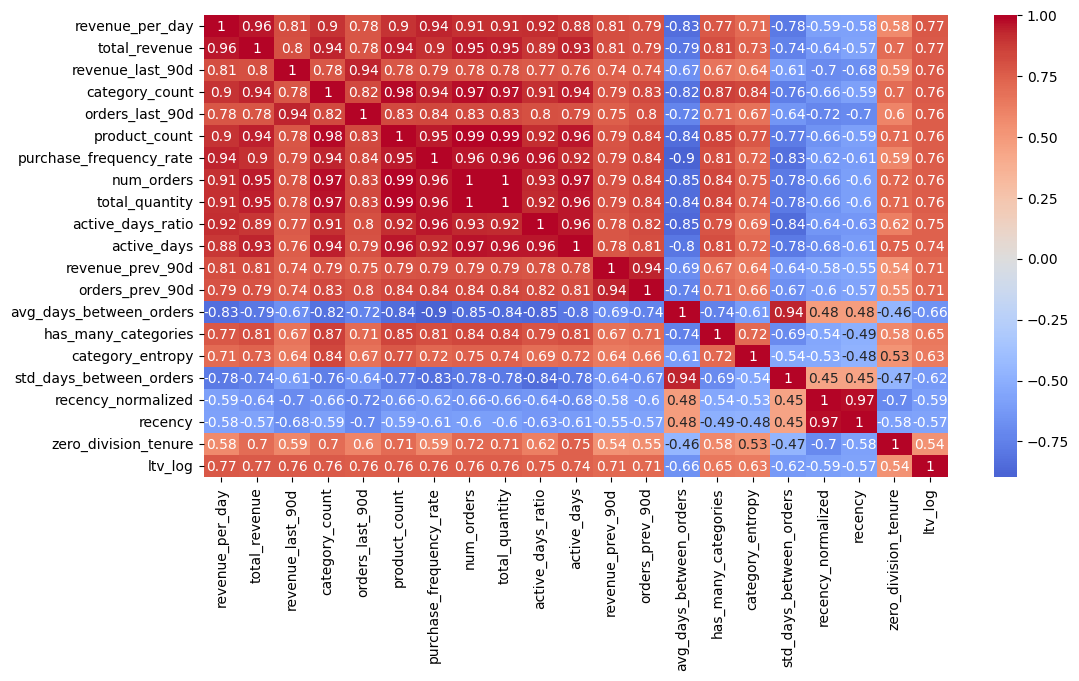

In [54]:
corr_ = cor_table['spearman_corr_ltv_log'].abs().sort_values(ascending=False).head(20).index.tolist()

plt.figure(figsize=(12,6))
sns.heatmap(data[corr_ + ['ltv_log']].corr(method='spearman'), cmap='coolwarm', center=0, annot=True)
plt.show()


In [55]:
corr_

['revenue_per_day',
 'total_revenue',
 'revenue_last_90d',
 'category_count',
 'orders_last_90d',
 'product_count',
 'purchase_frequency_rate',
 'num_orders',
 'total_quantity',
 'active_days_ratio',
 'active_days',
 'revenue_prev_90d',
 'orders_prev_90d',
 'avg_days_between_orders',
 'has_many_categories',
 'category_entropy',
 'std_days_between_orders',
 'recency_normalized',
 'recency',
 'zero_division_tenure']

# 7.2 Проверка мультиколлинеарности
Если признаки сильно коррелируют между собой, линейные модели могут быть нестабильны. Для деревьев это менее критично, но всё равно полезно понимать дублирование признаков.

In [56]:
corr_matrix = data[numeric_features].corr(method='spearman').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_spearman_corr'})
    .sort_values('abs_spearman_corr', ascending=False)
)
high_corr_pairs.head(25)

,feature_1,feature_2,abs_spearman_corr
586,customer_age,zero_division_customer,1.000000
617,tenure,zero_division_tenure,1.000000
46,num_orders,total_quantity,0.997377
55,num_orders,product_count,0.991838
961,orders_first_30d,quantity_first_30d,0.991587
139,avg_order_value,avg_unit_price,0.988986
99,total_quantity,product_count,0.988100
415,category_count,product_count,0.982024
562,recency,recency_normalized,0.973268
54,num_orders,category_count,0.973175


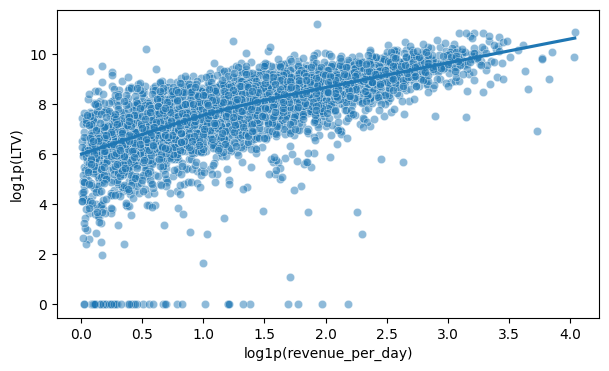

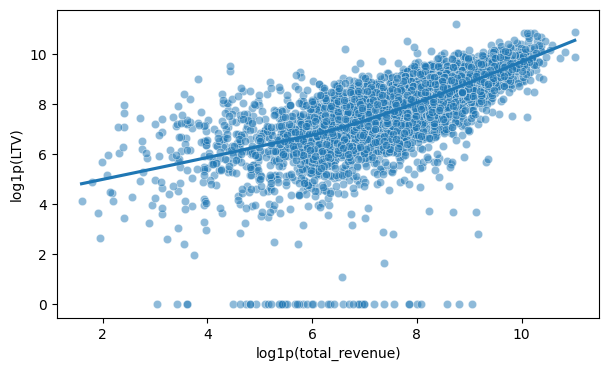

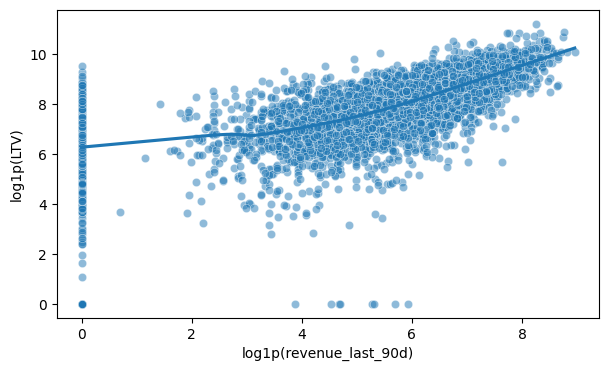

In [ ]:
plot_features = corr_[:8]

for col in plot_features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=np.log1p(data[col]), y=data['ltv_log'], alpha=0.5)
    sns.regplot(x=np.log1p(data[col]), y=data['ltv_log'], scatter=False, lowess=True)
    # plt.title(f'Зависимость log1p(LTV) от log1p({col})')
    plt.xlabel(f'log1p({col})')
    plt.ylabel('log1p(LTV)')
    plt.show()

In [ ]:
top_categories = data['top_category'].value_counts().head(20)
top_categories

In [ ]:
category_ltv = (
    data.groupby('top_category')
    .agg(users=('user_id', 'count'), median_ltv=('ltv', 'median'), mean_ltv=('ltv', 'mean'), median_ltv_log=('ltv_log', 'median'))
    .query('users >= 20')
    .sort_values('median_ltv_log', ascending=False)
)
category_ltv.head(20)

# Machine learning

In [ ]:
%%capture

!pip install category_encoders
!pip install catboost
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from category_encoders.cat_boost import CatBoostEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans

from sklearn.linear_model import ElasticNet, Lasso, Ridge

from catboost import CatBoostRegressor, Pool

from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, silhouette_score

In [ ]:
exclude = ['user_id', 'ltv', 'ltv_log', 'user_id', 'first_order_date', 'last_order_date']
features = [c for c in data.columns if c not in exclude]

X = data[features].copy()
y = data['ltv_log'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state= 42)

numeric_data = X.select_dtypes(include=[np.number]).columns.tolist()
text_data = X.select_dtypes(exclude=[np.number]).columns.tolist()


In [ ]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Рассмотрим распределение целевой переменной

In [ ]:
y.plot(kind='kde', title='Target density');

Dummy Regressor — базовая модель, которая поможет сравнивать модели для проверки качества.




Обработаем числовые признаки с помощью StandartScaler и SimpleImputer

In [ ]:
numeric_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_num = pd.DataFrame(
    numeric_pipline.fit_transform(X_train[numeric_data]),
    columns = numeric_data,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    numeric_pipline.transform(X_test[numeric_data]),
    columns=numeric_data,
    index=X_test.index
)

In [ ]:
clusters = [
    'recency',
    'num_orders',
    'avg_order_value',
    'purchase_frequency_rate',
    'avg_days_between_orders',
    'revenue_per_day',
    'category_count'
]

In [ ]:
clusters = [k for k in clusters if k in X_train_num.columns]
silhouette_scores = {}
for c in range(2, 5):
    kmeans = KMeans(n_clusters=c, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_num[clusters])
    silhouette_scores[c] = silhouette_score(X_train_num[clusters], labels)

silhouette_scores

In [ ]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_k

Обучим финальный K-means

In [ ]:
kmeans = KMeans(
    n_clusters = 3,
    random_state=42,
    n_init=10
)
X_train_cl = kmeans.fit_predict(X_train_num[clusters])
X_test_cl = kmeans.predict(X_test_num[clusters])

In [ ]:
X_train_num_copy = X_train_num.copy()
X_train_num_copy['cluster'] = X_train_cl

X_train_num_copy.groupby('cluster')[clusters].mean()

### визуализация

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_train_num[clusters])

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=X_train_cl,
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.title('K-Means clusters (PCA projection)')
plt.colorbar(scatter)
plt.show()

In [ ]:
cluster_profile = X_train_num_copy.groupby('cluster')[clusters].mean()
cluster_profile

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_profile = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

In [ ]:
categories = list(scaled_profile.columns)
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for cluster in scaled_profile.index:
    values = scaled_profile.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend()
# plt.title('Behavioral cluster profiles')
plt.show()

### обучение

In [ ]:
train_cluster_df = pd.get_dummies(
    X_train_cl,
    prefix='cluster',
    dtype=int
)

test_cluster_df = pd.get_dummies(
    X_test_cl,
    prefix='cluster',
    dtype=int
)

In [ ]:
train_cluster_df.index = X_train.index
test_cluster_df.index = X_test.index

In [ ]:
train_cluster_df, test_cluster_df = train_cluster_df.align(
    test_cluster_df,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
cat_encoder = CatBoostEncoder(cols=['top_category'])

X_train_cat = cat_encoder.fit_transform(
    X_train[['top_category']],
    y_train
)

X_test_cat = cat_encoder.transform(
    X_test[['top_category']]
)

In [ ]:
X_train = pd.concat(
    [X_train_num, X_train_cat, train_cluster_df],
    axis=1
)

X_test = pd.concat(
    [X_test_num, X_test_cat, test_cluster_df],
    axis=1
)

In [ ]:
dm = DummyRegressor()
dm.fit(X_train, y_train)
y_pred_dummy = dm.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred_dummy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2 = r2_score(y_test, y_pred_dummy)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

In [ ]:
lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2 = r2_score(y_test, y_pred_lasso)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

In [ ]:
def make_graph(actual, prediction, name):
  plt.figure(figsize=(12,8))
  results = pd.DataFrame({'True': actual, 'Prediction': prediction})
  sns.lmplot(x='True', y='Prediction', data=results, fit_reg=False)
  d_line = np.arange(results.min().min(), results.max().max())
  plt.plot(d_line, d_line, color='red', linestyle='--')
  plt.title = name
  plt.grid()
  plt.show()

In [ ]:
make_graph(y_test, y_pred_dummy, name='dummy')

In [ ]:
make_graph(y_test, y_pred_lr, name='Linear Regression')

In [ ]:
make_graph(y_test, y_pred_lasso, name='Lasso')

In [ ]:
elastic = ElasticNet(random_state=42, max_iter=10000)

elastic_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

elastic_search.fit(X_train, y_train)

elastic_best = elastic_search.best_estimator_
elastic_pred = elastic_best.predict(X_test)

In [ ]:
ridge = Ridge(random_state=42)

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100]
}

ridge_search = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

ridge_best = ridge_search.best_estimator_
ridge_pred = ridge_best.predict(X_test)

In [ ]:
lasso = Lasso(random_state=42, max_iter=10000)

lasso_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_search = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

lasso_best = lasso_search.best_estimator_
lasso_pred = lasso_best.predict(X_test)

In [ ]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'R2': [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ],
    'RMSE': [
        root_mean_squared_error(y_test, ridge_pred),
        root_mean_squared_error(y_test, lasso_pred),
        root_mean_squared_error(y_test, elastic_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred)
    ]
})

results.sort_values('R2', ascending=False)

Теперь проверим **Random Forest**,**XGBoost** (Extreme Gradient Boosting) и CatBoost

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

CatBoost

In [ ]:
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

In [ ]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

cat_model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

y_pred = cat_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("CatBoost results on ltv_log:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

y_test_ltv = np.expm1(y_test)
y_pred_ltv = np.expm1(y_pred)

mae_ltv = mean_absolute_error(y_test_ltv, y_pred_ltv)
rmse_ltv = np.sqrt(mean_squared_error(y_test_ltv, y_pred_ltv))
r2_ltv = r2_score(y_test_ltv, y_pred_ltv)

print("\nCatBoost results on original LTV scale:")
print(f"MAE:  {mae_ltv:.2f}")
print(f"RMSE: {rmse_ltv:.2f}")
print(f"R²:   {r2_ltv:.4f}")

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

In [ ]:
behavior_drop = [
    "total_revenue",
    "revenue_per_day",
    "avg_order_value",
    "median_order_value",
    "std_order_value",
    "min_order_value",
    "max_order_value",
    "revenue_first_30d",
    "avg_order_value_first_30d",
    "revenue_last_90d",
    "revenue_prev_90d",
    "revenue_trend_90d"
]

existing_drop = [c for c in behavior_drop if c in X.columns]

X_behavior = X.drop(columns=existing_drop)

cat_features_behavior = X_behavior.select_dtypes(
    include=["object", "category"]
).columns.tolist()

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_behavior,
    y,
    test_size=0.25,
    random_state=42
)

train_pool_b = Pool(
    X_train_b,
    y_train_b,
    cat_features=cat_features_behavior
)

test_pool_b = Pool(
    X_test_b,
    y_test_b,
    cat_features=cat_features_behavior
)

cat_behavior = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

cat_behavior.fit(
    train_pool_b,
    eval_set=test_pool_b,
    use_best_model=True
)

pred_b = cat_behavior.predict(X_test_b)

print("Behavior-only R²:", r2_score(y_test_b, pred_b))
print("Behavior-only RMSE:", np.sqrt(mean_squared_error(y_test_b, pred_b)))

RandomForest

In [ ]:

def evaluate_model(name, y_test, y_pred):
    return {
        'model': name,
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

In [ ]:
import time

rf = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])


params_grid = {
    'model__n_estimators': [300, 500, 700, 1000],
    'model__max_depth': [8, 10, 12, 15, 20, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.7],
    'model__bootstrap': [True]
}


rf_pipeline = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_grid,
    n_iter=60,
    cv=2,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=3,
    random_state=42
)

rf_pipline.fit(X_train, y_train)

y_preds_rf = rf_pipline.predict(X_test)
print(rf_pipline.best_params_)

In [ ]:
evaluate_model(name='Random search CV', y_test=y_test, y_pred=y_preds_rf)

In [ ]:
rf = RandomForestRegressor(random_state=2023)
parameters = {
    'n_estimators': [300, 500, 800, 1200],
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap': [True],
    'max_samples': [0.7, 0.8, 0.9, None]
}

rf_classifier = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2023, n_jobs=-1),
    param_distributions=parameters,
    n_iter=60,          # вместо всех 216 комбинаций
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=2023
)

rf_classifier.fit(X_train, y_train)


In [ ]:
y_preds_param_rf = rf_classifier.best_estimator_.predict(X_test)

print('Best Random Forest parameters:', rf_classifier.best_params_)

In [ ]:
print('R2:', r2_score(y_test, y_preds_param_rf))
print('RMSE:', root_mean_squared_error(y_test, y_preds_param_rf))
print('MSE:', mean_squared_error(y_test, y_preds_param_rf))


XGB Regressor

In [ ]:
xgb = XGBRegressor(objective='reg:squarederror')
xgb.fit(X_train, y_train)
y_preds_xgd = xgb.predict(X_test)

In [ ]:
print('RMSE:', root_mean_squared_error(y_test, y_preds_xgd))
print('MSE:', mean_squared_error(y_test, y_preds_xgd))
print('MAE:', mean_absolute_error(y_test, y_preds_xgd))
print('R2:', r2_score(y_test, y_preds_xgd))

In [ ]:
model = XGBRegressor()
parameters = {
    'n_estimators': [300, 500, 800, 1200, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.01, 0.05, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 3, 5, 10]
}

xgb_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=parameters,
    n_iter=60,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

xgb_random_search.fit(X_train, y_train)

In [ ]:
joblib.dump(xgb_random_search.best_estimator_, 'xgb_best_model.pkl')

In [ ]:
import joblib
joblib.dump(xgb_random_search.best_estimator_, 'xgb_best_model.pkl')

In [ ]:
joblib.dump(rf_classifier.best_estimator, 'xgb_best_model.pkl')


In [ ]:
import joblib
joblib.dump(xgb_random_search.best_estimator_, 'xgb_best_model.pkl')

In [ ]:
joblib.dump(rf_classifier.best_estimator_, 'rf_classifie.pkl')

In [ ]:
import joblib

joblib.dump(
    xgb_random_search.best_estimator_,
    '/content/drive/MyDrive/xgb_best_model.pkl'
)

In [ ]:
import joblib

joblib.dump(
   rf_classifier.best_estimator_, '/content/drive/MyDrive/rf_classifie.pkl')

In [ ]:
y_preds_xgdr = xgb_random_search.best_estimator_.predict(X_test)

In [ ]:
print('RMSE:', root_mean_squared_error(y_test, y_preds_xgdr))
print('MSE:', mean_squared_error(y_test, y_preds_xgdr))
print('MAE:', mean_absolute_error(y_test, y_preds_xgdr))
print('R2:', r2_score(y_test, y_preds_xgdr))

# Assesment of features